In [1]:
import os
from ModularCirc.Models.KorakianitisMixedModel import KorakianitisMixedModel, KorakianitisMixedModel_parameters, TEMPLATE_TIME_SETUP_DICT
from ModularCirc import BatchRunner
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import pickle
from cvdnet_pipeline.utils import helper_functions, plot_utils

### Plotting the emulator predicitons for true inputs versus emulator predicitons of calibrated kf inputs
 

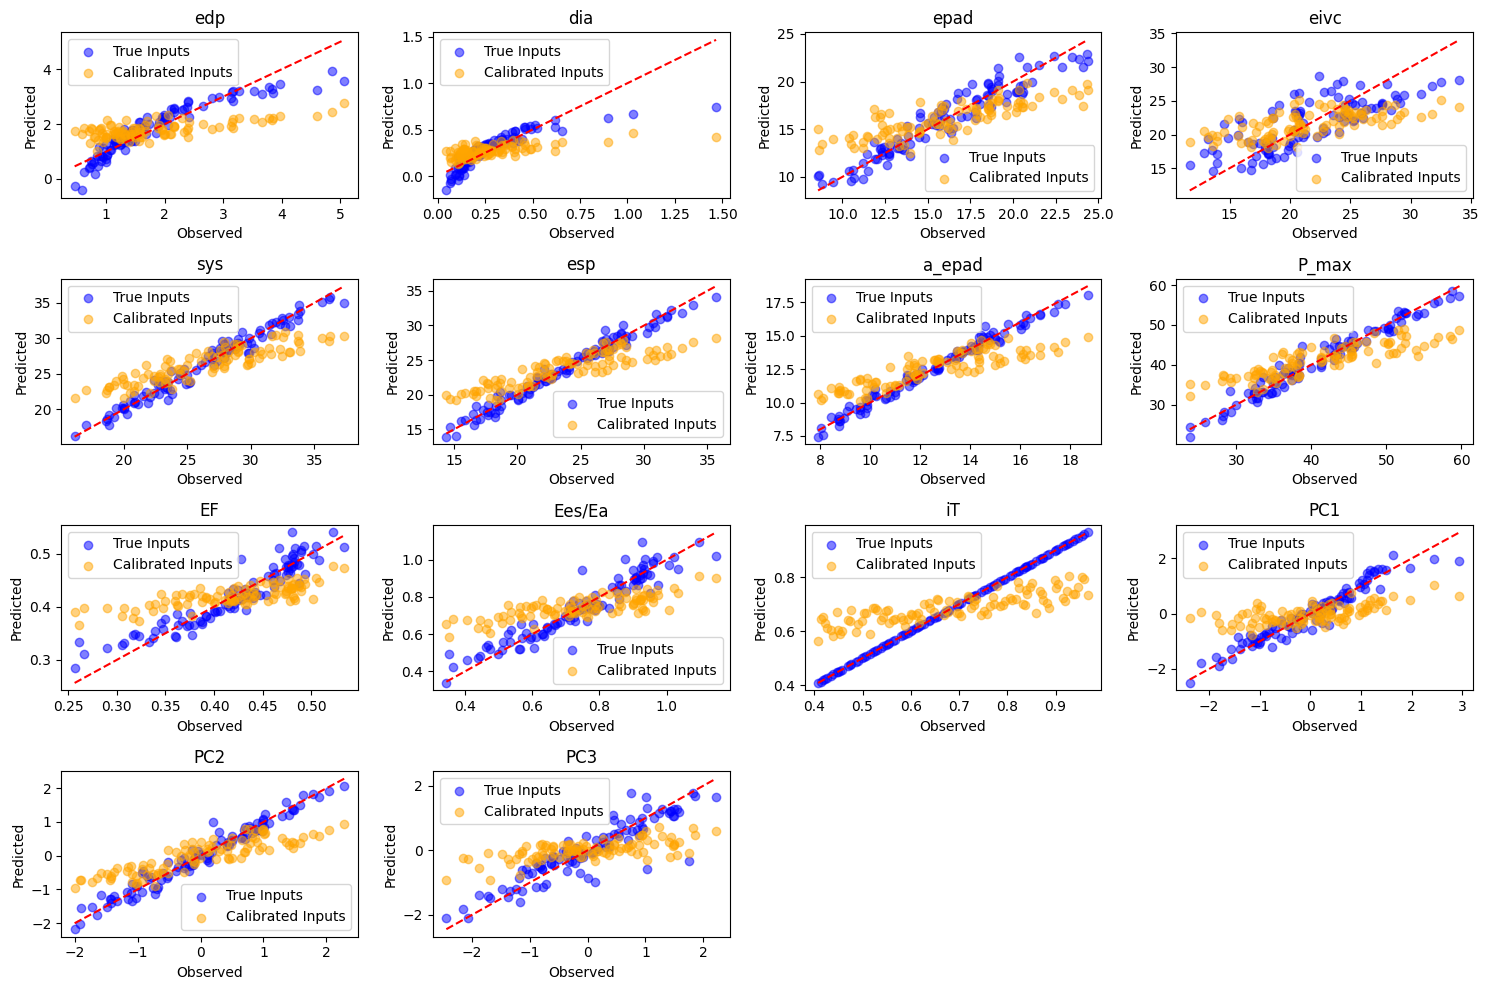

In [6]:
n_samples = 100
n_params = 6
data_type = "synthetic"
output_path = "../output_synthetic"

all_output_keys = [
        "edp",
        "dia",
        "epad",
        "eivc",
        "sys",
        "esp",
        "a_epad",
        "P_max",
        "EF",
        "Ees/Ea",
        "iT",
        "PC1",
        "PC2",
        "PC3"
    ]

calibration_path = "11_output_keys/calibration_20251216_143551/kf_estimated_means"

# Emulators
emulators= pd.read_pickle(f"{output_path}/output_{n_samples}_{n_params}_params/emulators/linear_models_and_r2_scores_{n_samples}.pkl")

# True imputs
true_inputs = pd.read_csv(f"{output_path}/pure_input_{n_samples}_{n_params}_params.csv")

# True outputs
true_output = pd.read_csv(f"{output_path}/output_{n_samples}_{n_params}_params/waveform_resampled_all_pressure_traces_rv_with_pca.csv")

# Calibrated inputs
calibrated_inputs = pd.read_csv(f"{output_path}/output_{n_samples}_{n_params}_params/kf_calibration_results/{calibration_path}.csv")

# Select emulators and data for specified output_keys
emulator_output = emulators.loc[all_output_keys]
observation_data = true_output.loc[:, all_output_keys] 

# Model error (RMSE from cross-validation)
model_error = np.array(emulator_output['RMSE']).reshape(14,1)

# Construct beta matrix and intercepts
beta_matrix = []
intercept = []

for _, row_entry in emulator_output.iterrows():
    model = row_entry['Model']
    beta_matrix.append(model.coef_)
    intercept.append(model.intercept_)

beta_matrix = np.array(beta_matrix)
intercept = np.array(intercept).reshape(len(intercept), 1)

# emulator predictions for true inputs
emulator_predictions_true = np.dot(beta_matrix, true_inputs.T) + intercept
emulator_predictions_true = pd.DataFrame(emulator_predictions_true.T, columns=all_output_keys)


# emulator predictions for calibrated inputs
emulator_predictions_calibrated = np.dot(beta_matrix, calibrated_inputs.T) + intercept 
emulator_predictions_calibrated = pd.DataFrame(emulator_predictions_calibrated.T, columns=all_output_keys)


# Plot results
plt.figure(figsize=(15, 10))
for i, key in enumerate(all_output_keys):
    plt.subplot(4, 4, i+1)
    plt.scatter(observation_data[key], emulator_predictions_true[key], label='True Inputs', alpha=0.5, c='blue')
    plt.scatter(observation_data[key], emulator_predictions_calibrated[key], label='Calibrated Inputs', alpha=0.5, c='orange')
    plt.plot([observation_data[key].min(), observation_data[key].max()], 
             [observation_data[key].min(), observation_data[key].max()], 'r--')
    plt.xlabel('Observed')
    plt.ylabel('Predicted')
    plt.title(key)
    plt.legend()
plt.tight_layout()




### True values of output against emulated output using true input value and emulated output using claibrated input

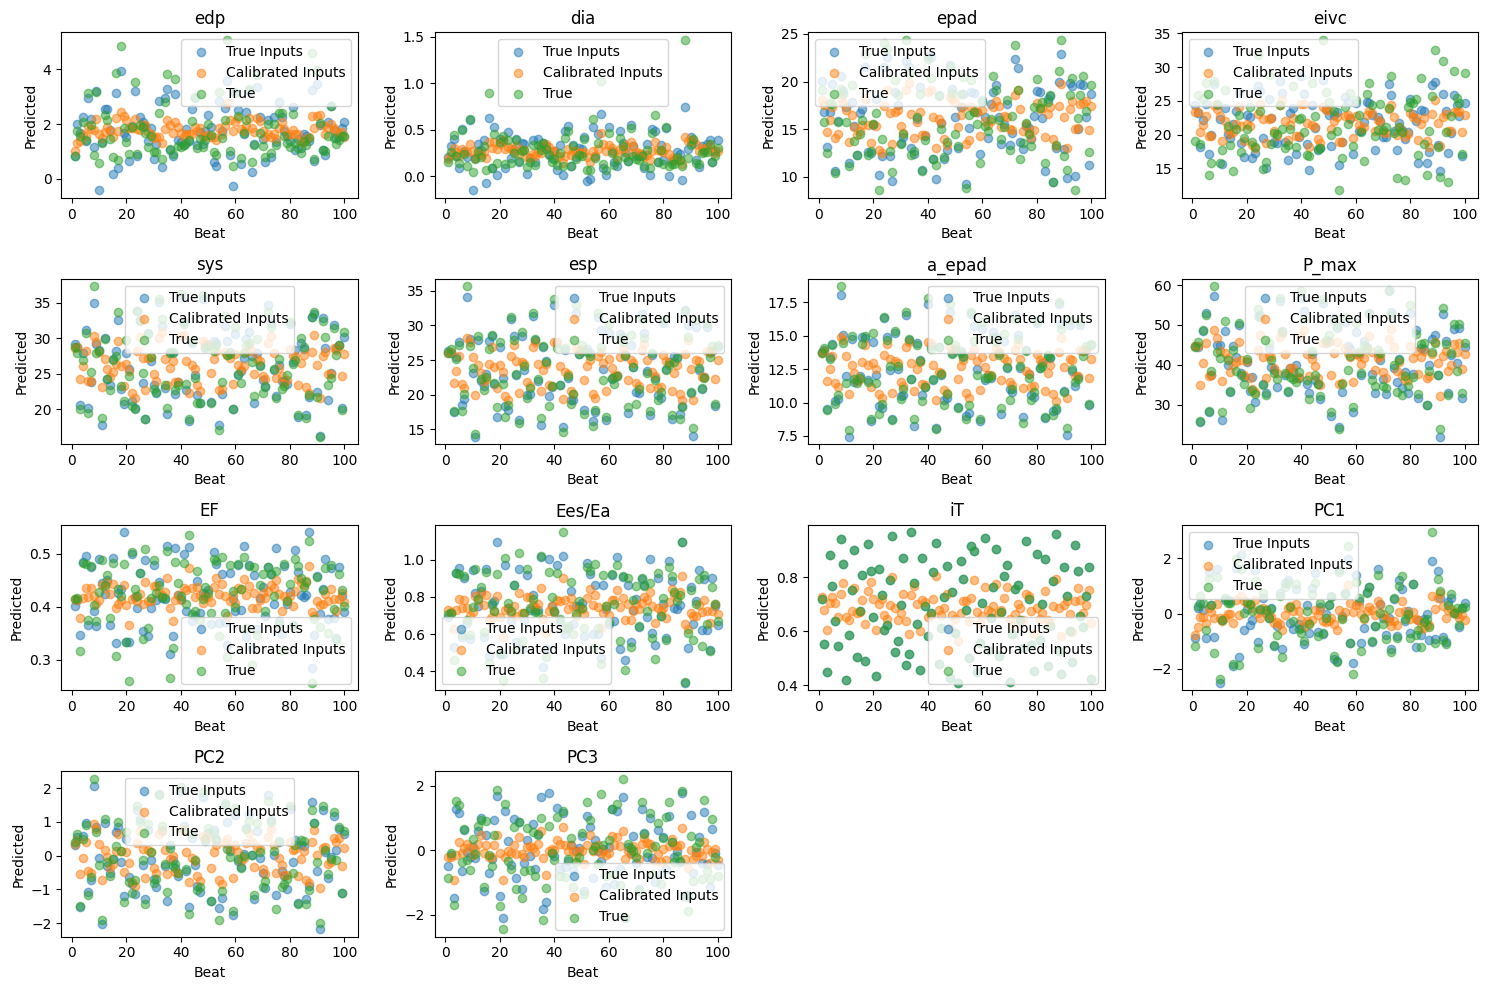

In [7]:
X = np.arange(1,101)
plt.figure(figsize=(15, 10))
for i, key in enumerate(all_output_keys):
    plt.subplot(4, 4, i+1)
    plt.scatter(X, emulator_predictions_true[key], label='True Inputs', alpha=0.5)
    plt.scatter(X, emulator_predictions_calibrated[key], label='Calibrated Inputs', alpha=0.5)
    plt.scatter(X, observation_data[key], label='True', alpha=0.5)
    plt.xlabel('Beat')
    plt.ylabel('Predicted')
    plt.title(key)
    plt.legend()
plt.tight_layout()

### Prediciton error across beats for each output using B2B versus KF calibration

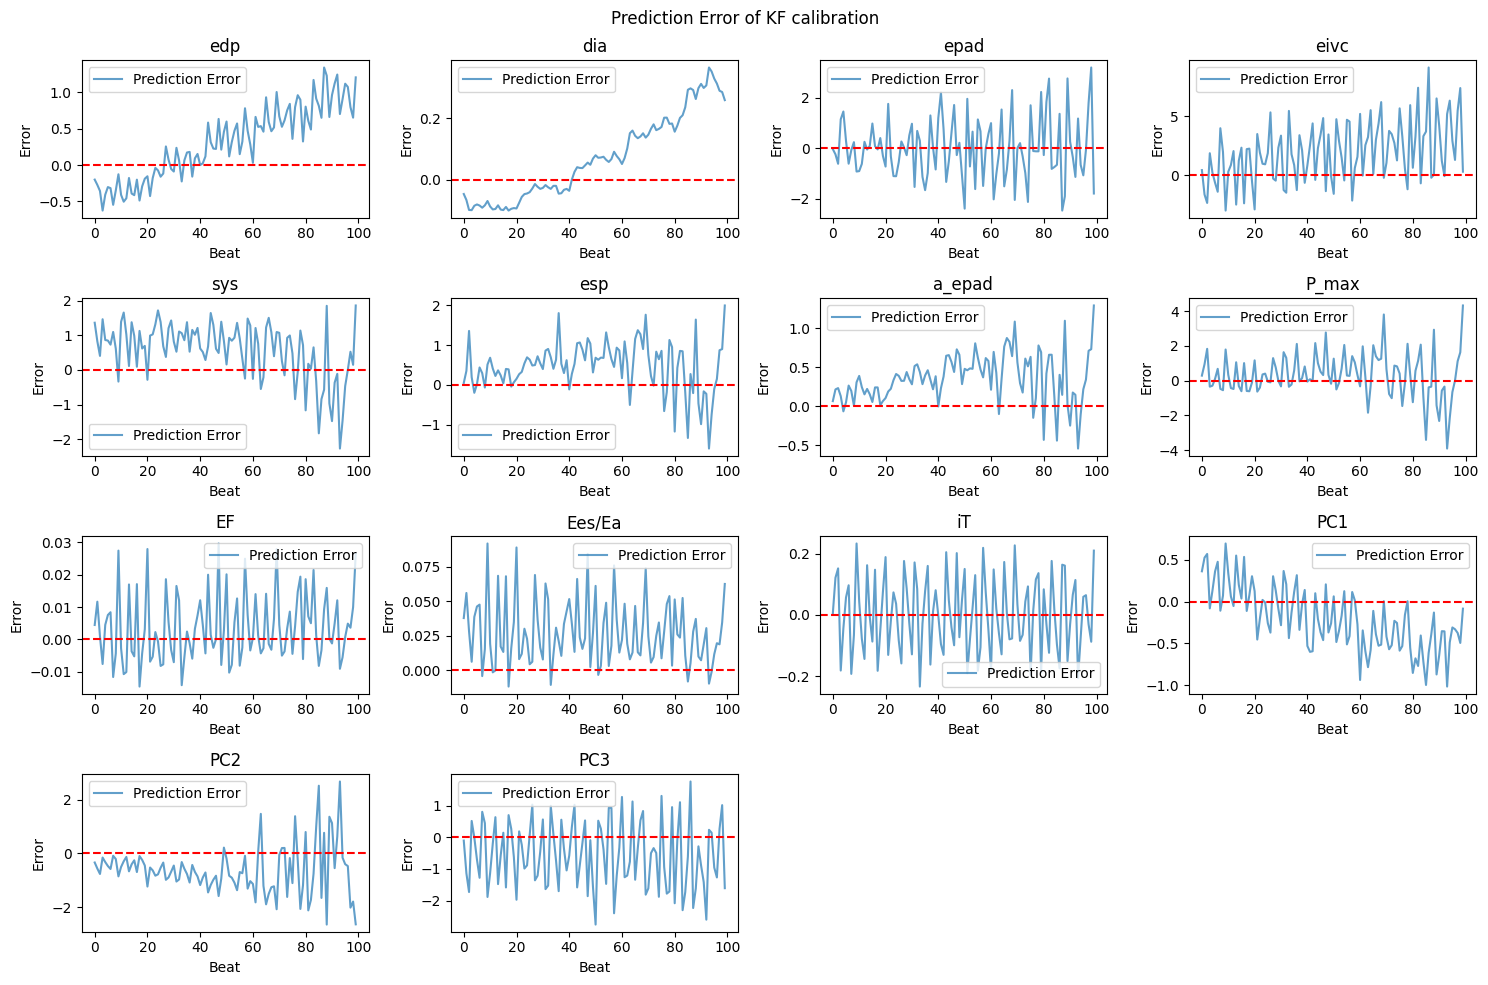

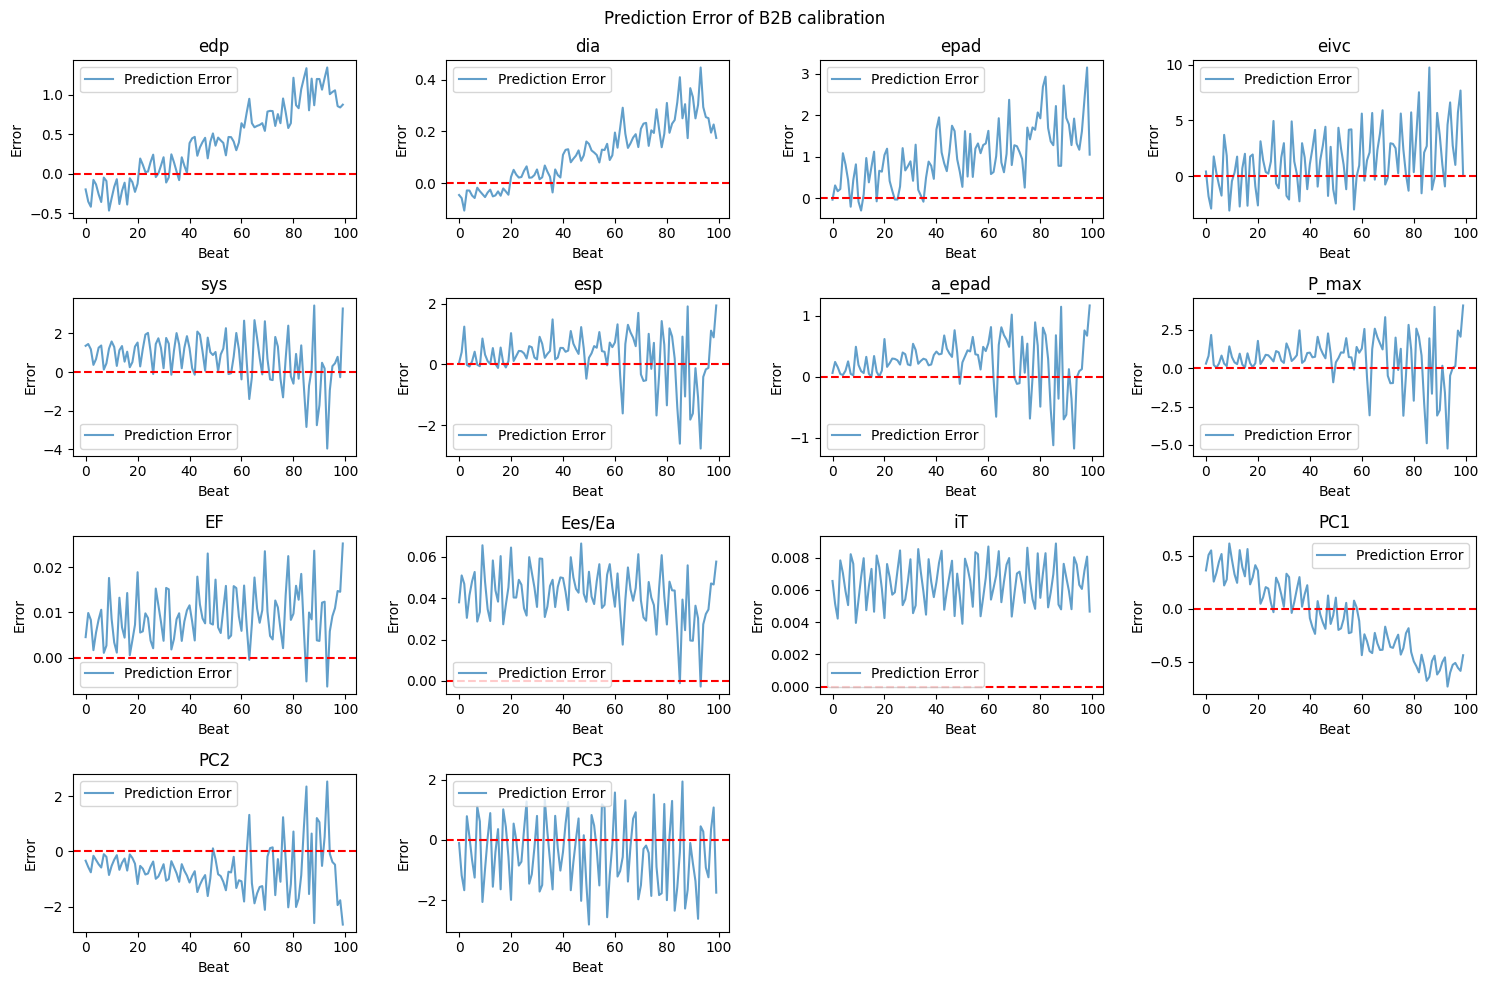

In [14]:
n_samples = 1024
n_params = 6
data_type = "real"
emulator_path = "../output_synthetic"
data_path = "../CohortDataRaw2/output_real/pat_synthetic_6_RC_rveact_epas_kpas"

all_output_keys = [
        "edp",
        "dia",
        "epad",
        "eivc",
        "sys",
        "esp",
        "a_epad",
        "P_max",
        "EF",
        "Ees/Ea",
        "iT",
        "PC1",
        "PC2",
        "PC3"
    ]

calibration_path_kf = "kf_calibration_results/14_output_keys/kf_calibration_results/14_output_keys/calibration_20251027_162822/kf_estimated_means.csv"
calibration_path_b2b = "bayesian_calibration_results/14_output_keys/calibration_20251027_162822/posterior_mean.csv"

# Emulators
emulators= pd.read_pickle(f"{emulator_path}/output_{n_samples}_{n_params}_params/emulators/linear_models_and_r2_scores_{n_samples}.pkl")


# True output data
true_output = pd.read_csv(f"{data_path}/waveform_resampled_all_pressure_traces_rv_with_pca.csv")

# Calibrated inputs
calibrated_inputs_kf = pd.read_csv(f"{data_path}/{calibration_path_kf}")
calibrated_inputs_b2b = pd.read_csv(f"{data_path}/{calibration_path_b2b}")

# Select emulators and data for specified output_keys
emulator_output = emulators.loc[all_output_keys]
observation_data = true_output.loc[:, all_output_keys] 


# Construct beta matrix and intercepts
beta_matrix = []
intercept = []

for _, row_entry in emulator_output.iterrows():
    model = row_entry['Model']
    beta_matrix.append(model.coef_)
    intercept.append(model.intercept_)

beta_matrix = np.array(beta_matrix)
intercept = np.array(intercept).reshape(len(intercept), 1)


# emulator predictions for calibrated inputs
emulator_predictions_calibrated_kf = np.dot(beta_matrix, calibrated_inputs_kf.T) + intercept 
emulator_predictions_calibrated_kf = pd.DataFrame(emulator_predictions_calibrated_kf.T, columns=all_output_keys)

emulator_predictions_calibrated_b2b = np.dot(beta_matrix, calibrated_inputs_b2b.T) + intercept 
emulator_predictions_calibrated_b2b = pd.DataFrame(emulator_predictions_calibrated_b2b.T, columns=all_output_keys)


# prediction error (between emulator predictions and observed data)
prediction_error_kf = emulator_predictions_calibrated_kf.values - observation_data.values
prediction_error_kf_df = pd.DataFrame(prediction_error_kf, columns=all_output_keys)
prediction_error_b2b = emulator_predictions_calibrated_b2b.values - observation_data.values
prediction_error_b2b_df = pd.DataFrame(prediction_error_b2b, columns=all_output_keys)

# Plot prediction error through time for each output key
plt.figure(figsize=(15, 10))
for i, key in enumerate(all_output_keys):
    plt.subplot(4, 4, i+1)
    plt.plot(prediction_error_kf[:, i], label='Prediction Error', alpha=0.7)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Beat')
    plt.ylabel('Error')
    plt.title(f'{key}')
    plt.legend()
plt.suptitle('Prediction Error of KF calibration')
plt.tight_layout()

plt.figure(figsize=(15, 10))
for i, key in enumerate(all_output_keys):       
    plt.subplot(4, 4, i+1)
    plt.plot(prediction_error_b2b[:, i], label='Prediction Error', alpha=0.7)
    plt.axhline(0, color='r', linestyle='--')
    plt.xlabel('Beat')
    plt.ylabel('Error')
    plt.title(f'{key}')
    plt.legend()
plt.suptitle('Prediction Error of B2B calibration')
plt.tight_layout()



### Computing conditon number from eigenvectors

eigenvectors:           0         1         2         3         4         5
0  0.226422  0.967686 -0.059474 -0.043304  0.075301 -0.035116
1 -0.013826 -0.060005  0.085372  0.290282  0.887286 -0.342606
2 -0.016072 -0.002103 -0.002060  0.000988 -0.360610 -0.932573
3  0.018995  0.039583 -0.301925  0.918774 -0.233260  0.091421
4 -0.973334  0.228645  0.001800  0.010039  0.002713  0.015216
5 -0.023322 -0.078311 -0.947633 -0.263844  0.150317 -0.055733
eigenvalues:               0
0  98645.687390
1   3120.266422
2    153.070053
3      9.621090
4      0.728743
5      0.114663
smallest eigenvalue index: 5
smallest eigenvalue: 0.11466337827657996
corresponding eigenvector (weights on params): [-0.035116   -0.34260637 -0.93257289  0.09142124  0.01521597 -0.05573319]
condition number: 860306.829193156
approx variance along that direction (1/lambda): 8.721180337002599


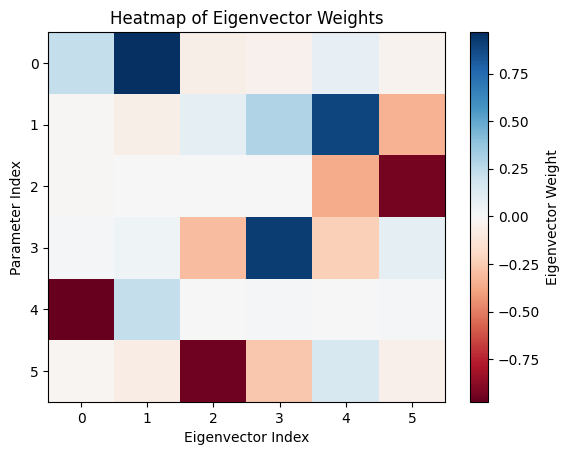

In [15]:
eigen = beta_matrix.T @ beta_matrix
eigenvalues, eigenvectors = np.linalg.eig(eigen)
pd.DataFrame(eigenvectors), pd.DataFrame(eigenvalues)

import numpy as np

V = eigenvectors
lambdas = eigenvalues

print("eigenvectors:",  pd.DataFrame(V))
print("eigenvalues:", pd.DataFrame(lambdas))

min_idx = np.argmin(lambdas)
print("smallest eigenvalue index:", min_idx)
print("smallest eigenvalue:", lambdas[min_idx])
print("corresponding eigenvector (weights on params):", V[:, min_idx])
print("condition number:", lambdas.max()/lambdas.min())
print("approx variance along that direction (1/lambda):", 1.0/lambdas[min_idx])


plt.figure()
plt.imshow(V, aspect='auto', cmap='RdBu')
plt.colorbar(label="Eigenvector Weight")
plt.xlabel("Eigenvector Index")
plt.ylabel("Parameter Index")
plt.title("Heatmap of Eigenvector Weights")
plt.show()

In [16]:
# emu error
emu_error = emulator_output['RMSE']

# observed error
epsilon_obs_scale = 0.05
sd_values = observation_data[all_output_keys].std().values
diagonal_values = sd_values
e_obs = diagonal_values * epsilon_obs_scale

error_values = emu_error**2 + e_obs**2
error_values**(1/2)

edp       0.675860
dia       0.282762
epad      1.702745
eivc      3.846380
sys       1.715130
esp       1.749079
a_epad    0.902601
P_max     3.400684
EF        0.026376
Ees/Ea    0.057445
iT        0.008164
PC1       0.290194
PC2       0.237413
PC3       0.810169
Name: RMSE, dtype: float64

### Plot likelihood comparison thorugh time for B2B and KF calibration 

/var/folders/28/nchybyxs1ps5wk3zmnqdpd8r0000gr/T/ipykernel_96286/3377468447.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  error = error_values[i]
/var/folders/28/nchybyxs1ps5wk3zmnqdpd8r0000gr/T/ipykernel_96286/3377468447.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  error = error_values[i]


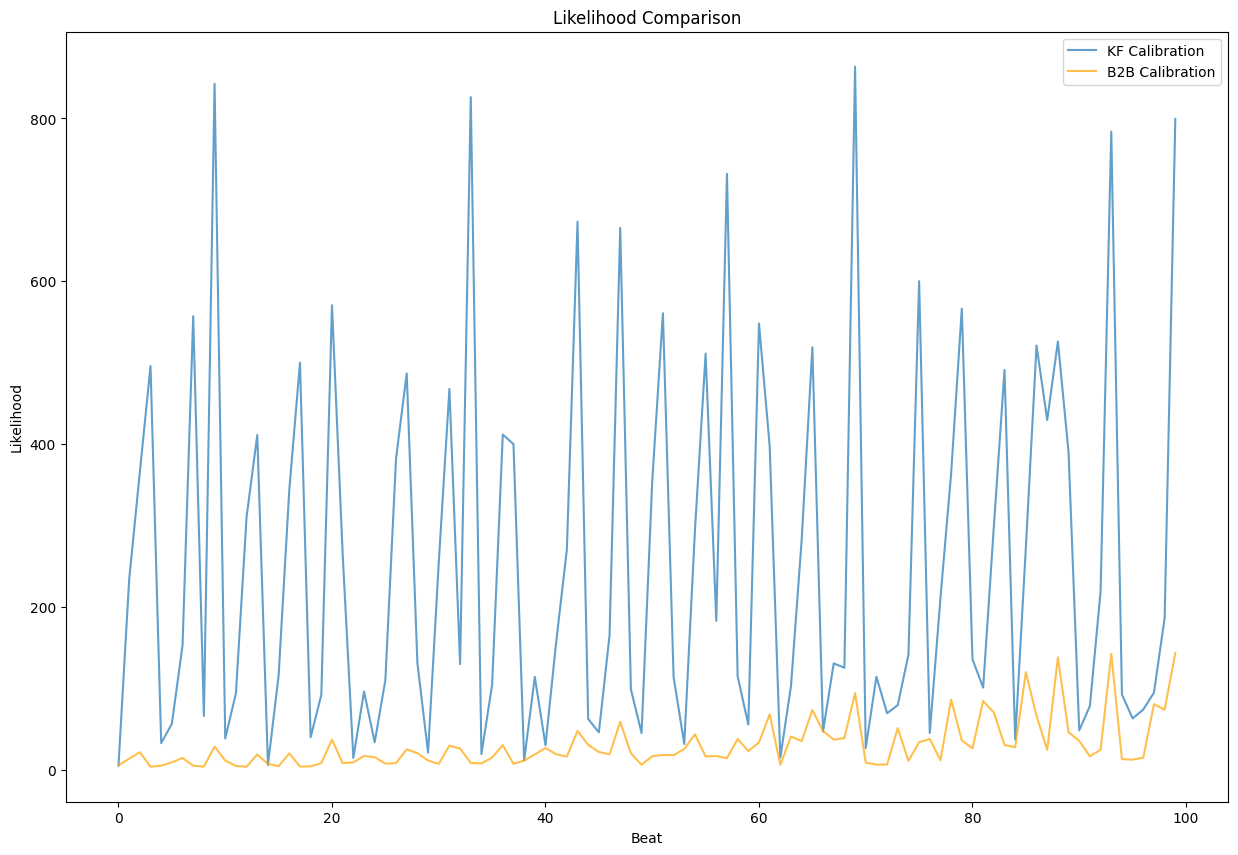

In [18]:
# compute likelihood for each output key for each row
likelihoods_kf= []
for row in range(len(prediction_error_kf_df)):
    likelihood_row = 0
    for i, key in enumerate(all_output_keys):
        error = error_values[i]
        residuals = prediction_error_kf_df.loc[row, key]
        likelihood_row += np.sum((residuals ** 2) / error ) 
    likelihoods_kf.append(likelihood_row)  

likelihoods_b2b= []
for row in range(len(prediction_error_b2b_df)):
    likelihood_row = 0
    for i, key in enumerate(all_output_keys):
        error = error_values[i]
        residuals = prediction_error_b2b_df.loc[row, key]
        likelihood_row += np.sum((residuals ** 2) / error )
    likelihoods_b2b.append(likelihood_row)



# Plot likelihood through time for kf and b2b calibration
plt.figure(figsize=(15, 10))
plt.plot(likelihoods_kf, label='KF Calibration', alpha=0.7)
plt.plot(likelihoods_b2b, label='B2B Calibration', alpha=0.7, color='orange')
plt.xlabel('Beat')
plt.ylabel('Likelihood')
plt.title('Likelihood Comparison')  
plt.legend()

### Correlation matrix 


In [25]:
Sigma = pd.read_csv('../output_synthetic/output_4096_6_params/bayesian_calibration_results/11_output_keys/calibration_20251215_110034/posterior_covariance.csv')
Sigma

,pat.r,pat.c,rv.E_pas,rv.E_act,rv.k_pas,T
0,0.000723,0.016577,0.000121,-0.002862,0.000008,0.000013
1,0.016577,0.594737,0.002560,-0.035841,0.000197,0.000181
2,0.000121,0.002560,0.028867,0.007309,-0.000378,-0.000022
3,-0.002862,-0.035841,0.007309,0.102727,0.000235,-0.000110
4,0.000008,0.000197,-0.000378,0.000235,0.000015,-0.000001
5,0.000013,0.000181,-0.000022,-0.000110,-0.000001,0.000093


In [26]:
import numpy as np
import matplotlib.pyplot as plt

class CorrelationPlot:
    def __init__(self, covariance_matrix):
        # If input is a DataFrame, extract labels
        if isinstance(covariance_matrix, pd.DataFrame):
            self.cov = covariance_matrix.values
            self.labels = list(covariance_matrix.columns)
        else:
            self.cov = np.array(covariance_matrix)
            self.labels = [f"Var{i+1}" for i in range(self.cov.shape[0])]

        self.corr = self._compute_correlation()

    def _compute_correlation(self):
        """Compute correlation matrix from covariance matrix."""
        stddev = np.sqrt(np.diag(self.cov))
        return self.cov / np.outer(stddev, stddev)

    def plot_heatmap(self, cmap="coolwarm", vmin=-1, vmax=1, show_values=False):
        """Plot heatmap of correlation matrix."""
        fig, ax = plt.subplots()
        cax = ax.matshow(self.corr, cmap=cmap, vmin=vmin, vmax=vmax)
        fig.colorbar(cax)

        # Axis ticks
        ax.set_xticks(range(len(self.labels)))
        ax.set_yticks(range(len(self.labels)))
        ax.set_xticklabels(self.labels, rotation=45, ha="left")
        ax.set_yticklabels(self.labels)

        # Optional annotations
        if show_values:
            for i in range(self.corr.shape[0]):
                for j in range(self.corr.shape[1]):
                    ax.text(j, i, f"{self.corr[i, j]:.2f}", va="center", ha="center", color="black")

        plt.show()


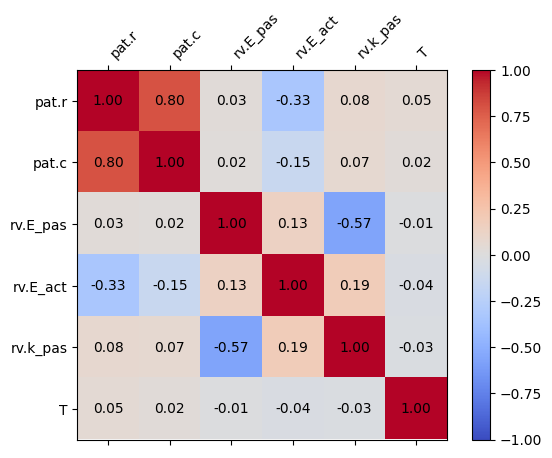

In [27]:
cp = CorrelationPlot(Sigma)
cp.plot_heatmap(show_values=True)